# Air-gap and manufacturing sensitivity

How much do air-gap error, rotor coning, runout, and magnet arc hurt
performance? These are the manufacturing questions that decide whether a
paper design survives the shop floor.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from axfluxmdo import AxialFluxMotor, OperatingPoint
from axfluxmdo.models import AnnularModel
from axfluxmdo.sweeps import sweep_parameter

OUTPUT_DIR = Path(__file__).parent / "output" if "__file__" in globals() else Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

motor = AxialFluxMotor(
    outer_radius=0.08,
    inner_radius=0.025,
    air_gap=0.0008,
    pole_pairs=14,
    phases=3,
    turns_per_phase=24,
    fill_factor=0.45,
    magnet_thickness=0.004,
    back_iron_thickness=0.006,
)
op = OperatingPoint(speed_rpm=500, current_rms=25, dc_bus_voltage=48)
model = AnnularModel(n_slices=32)

## Nominal air gap

The dominant design sensitivity: torque falls steeply as the gap opens.

In [2]:
gap_sweep = sweep_parameter(motor, op, "air_gap", np.linspace(0.0005, 0.002, 13), model=model)
data = gap_sweep.to_arrays("torque_nm", "efficiency")
t_nominal = model.evaluate(motor, op).torque_nm
print(f"torque at 0.5 mm gap: {data['torque_nm'][0]:.2f} N·m")
print(f"torque at 0.8 mm gap: {t_nominal:.2f} N·m (nominal)")
print(f"torque at 2.0 mm gap: {data['torque_nm'][-1]:.2f} N·m")

torque at 0.5 mm gap: 9.23 N·m
torque at 0.8 mm gap: 8.63 N·m (nominal)
torque at 2.0 mm gap: 6.85 N·m


## Manufacturing imperfections (dotted-path sweeps)

Each tolerance field sweeps directly. Note the runout result: the load line
B(g) is **convex** in g, so by Jensen's inequality the circumferential mean
flux — and hence mean torque — *rises* slightly with runout. Runout's real
costs are the once-per-revolution torque/force modulation (`torque_ripple_proxy`)
and the axial-force imbalance, not mean torque.

In [3]:
offset_sweep = sweep_parameter(
    motor, op, "tolerances.gap_offset_m", np.linspace(0, 3e-4, 7), model=model
)
coning_sweep = sweep_parameter(
    motor, op, "tolerances.coning_m", np.linspace(-4e-4, 4e-4, 9), model=model
)
runout_sweep = sweep_parameter(
    motor, op, "tolerances.runout_m", np.linspace(0, 4e-4, 9), model=model
)

for label, sweep in (("offset", offset_sweep), ("coning", coning_sweep), ("runout", runout_sweep)):
    torques = [r.torque_nm for r in sweep.results]
    print(f"{label:8s} torque range: {min(torques):.3f} … {max(torques):.3f} N·m")

ripples = [r.torque_ripple_proxy for r in runout_sweep.results]
print(f"runout ripple proxy at 0.4 mm: {ripples[-1]:.1%}")

offset   torque range: 8.102 … 8.629 N·m
coning   torque range: 8.569 … 8.700 N·m
runout   torque range: 8.629 … 8.662 N·m
runout ripple proxy at 0.4 mm: 8.7%


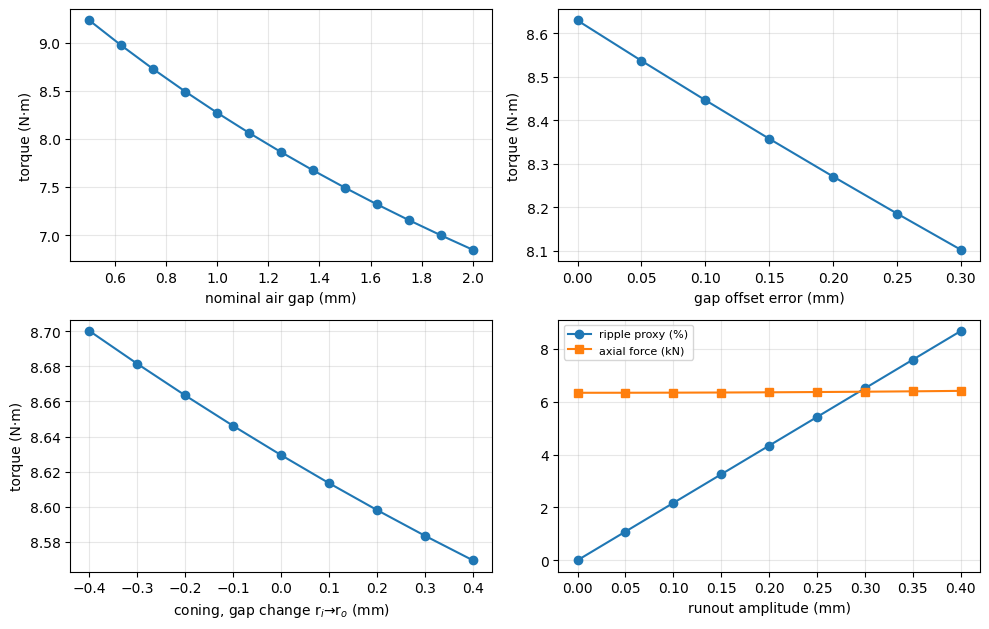

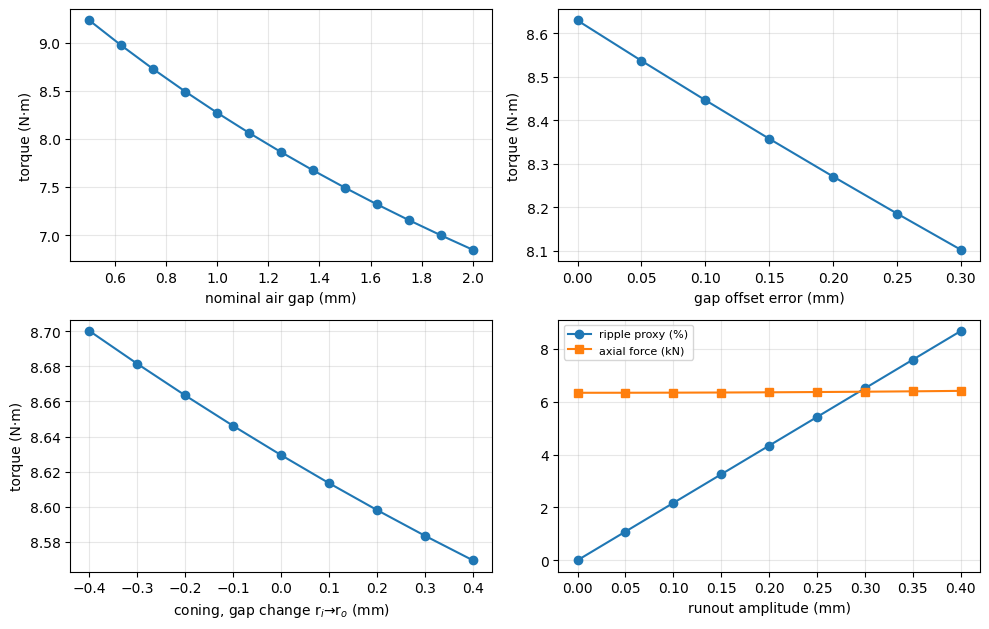

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6.4))

ax = axes[0, 0]
ax.plot(np.asarray(gap_sweep.values) * 1e3, data["torque_nm"], "o-")
ax.set_xlabel("nominal air gap (mm)")
ax.set_ylabel("torque (N·m)")

ax = axes[0, 1]
ax.plot(np.asarray(offset_sweep.values) * 1e3, [r.torque_nm for r in offset_sweep.results], "o-")
ax.set_xlabel("gap offset error (mm)")
ax.set_ylabel("torque (N·m)")

ax = axes[1, 0]
ax.plot(np.asarray(coning_sweep.values) * 1e3, [r.torque_nm for r in coning_sweep.results], "o-")
ax.set_xlabel("coning, gap change r$_i$→r$_o$ (mm)")
ax.set_ylabel("torque (N·m)")

ax = axes[1, 1]
runout_mm = np.asarray(runout_sweep.values) * 1e3
ripple_pct = [100 * r.torque_ripple_proxy for r in runout_sweep.results]
force_kn = [r.axial_force_n / 1e3 for r in runout_sweep.results]
ax.plot(runout_mm, ripple_pct, "o-", label="ripple proxy (%)")
ax.plot(runout_mm, force_kn, "s-", label="axial force (kN)")
ax.set_xlabel("runout amplitude (mm)")
ax.legend(fontsize=8)

for ax in axes.flat:
    ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "04_air_gap_sensitivity.png", dpi=150, bbox_inches="tight")
fig

## Magnet arc ratio

Wider magnets add flux (more torque) but also more magnet mass and higher
yoke loading — the fundamental-harmonic factor sin(α·π/2) saturates near
full coverage, so the last 10 % of arc buys very little.

In [5]:
arc_sweep = sweep_parameter(motor, op, "magnet_arc_ratio", np.linspace(0.5, 1.0, 11), model=model)
for alpha, r in zip(arc_sweep.values, arc_sweep.results, strict=True):
    magnet_kg = r.mass_breakdown["magnets"]
    print(f"alpha={alpha:.2f}  torque={r.torque_nm:.2f} N·m  magnet mass={magnet_kg:.3f} kg")

alpha=0.50  torque=6.28 N·m  magnet mass=0.272 kg
alpha=0.55  torque=6.75 N·m  magnet mass=0.299 kg
alpha=0.60  torque=7.18 N·m  magnet mass=0.327 kg
alpha=0.65  torque=7.57 N·m  magnet mass=0.354 kg
alpha=0.70  torque=7.91 N·m  magnet mass=0.381 kg
alpha=0.75  torque=8.20 N·m  magnet mass=0.408 kg
alpha=0.80  torque=8.44 N·m  magnet mass=0.435 kg
alpha=0.85  torque=8.63 N·m  magnet mass=0.463 kg
alpha=0.90  torque=8.77 N·m  magnet mass=0.490 kg
alpha=0.95  torque=8.85 N·m  magnet mass=0.517 kg
alpha=1.00  torque=8.87 N·m  magnet mass=0.544 kg
